**Импорт необходимых библиотек**

In [9]:
import pandas as pd
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

**Загрузка данных**

In [10]:
acc_path = 'C:/Users/Andrei/PycharmProjects/HW_Adv_ROB/data/RO_HW_3_data/Accelerometer.csv'
gyro_path = 'C:/Users/Andrei/PycharmProjects/HW_Adv_ROB/data/RO_HW_3_data/Gyroscope.csv'

df_acc = pd.read_csv(acc_path)
df_gyro = pd.read_csv(gyro_path)

df_acc = df_acc.rename(columns={
    'x': 'accel_x',
    'y': 'accel_y',
    'z': 'accel_z'
})

df_gyro = df_gyro.rename(columns={
    'x': 'gyro_x',
    'y': 'gyro_y',
    'z': 'gyro_z'
})

# Используем seconds_elapsed как основное время
if 'seconds_elapsed' in df_acc.columns and 'seconds_elapsed' in df_gyro.columns:
    t_acc = df_acc['seconds_elapsed'].values
    t_gyro = df_gyro['seconds_elapsed'].values
else:
    t_acc = (df_acc['time'] - df_acc['time'].iloc[0]) / 1e9
    t_gyro = (df_gyro['time'] - df_gyro['time'].iloc[0]) / 1e9

common_t = np.sort(np.unique(np.concatenate([t_acc, t_gyro])))

# Интерполяция accel на common_t
accel_interp = np.column_stack([
    np.interp(common_t, t_acc, df_acc['accel_x']),
    np.interp(common_t, t_acc, df_acc['accel_y']),
    np.interp(common_t, t_acc, df_acc['accel_z'])
])

# Интерполяция gyro на common_t
gyro_interp = np.column_stack([
    np.interp(common_t, t_gyro, df_gyro['gyro_x']),
    np.interp(common_t, t_gyro, df_gyro['gyro_y']),
    np.interp(common_t, t_gyro, df_gyro['gyro_z'])
])

t = common_t
accel = accel_interp
gyro = gyro_interp

dt_mean = np.mean(np.diff(t))
print(f"Данные синхронизированы: {len(t)} точек, средний dt = {dt_mean:.4f} с")

Данные синхронизированы: 5669 точек, средний dt = 0.0102 с


**Параметры EKF**

In [11]:
g = 9.81
g_global = np.array([0.0, 0.0, -g])

Q_euler = np.eye(3) * 5e-4
Q_quat  = np.eye(4) * 1e-6
R       = np.eye(3) * (0.08 ** 2)     # предполагаемый шум акселерометра ~8 см/с²
P0      = np.eye(4) * 0.05**2         # начальная ковариация

**Вспомогательные функции**

In [12]:
def quat_mult(q, p):
    qw, qx, qy, qz = q
    pw, px, py, pz = p
    return np.array([
        qw*pw - qx*px - qy*py - qz*pz,
        qw*px + qx*pw + qy*pz - qz*py,
        qw*py - qx*pz + qy*pw + qz*px,
        qw*pz + qx*py - qy*px + qz*pw
    ])

def quat_to_euler(q):
    w, x, y, z = q / np.linalg.norm(q)
    roll  = np.arctan2(2*(w*x + y*z), 1 - 2*(x**2 + y**2))
    pitch = np.arcsin (2*(w*y - z*x))
    yaw   = np.arctan2(2*(w*z + x*y), 1 - 2*(y**2 + z**2))
    return np.degrees([roll, pitch, yaw])

def numerical_jacobian(f, x, *args, eps=1e-6):
    x = np.asarray(x, dtype=float)
    fx = f(x, *args)
    J = np.zeros((len(fx), len(x)))
    for j in range(len(x)):
        xj = x.copy()
        xj[j] += eps
        J[:,j] = (f(xj, *args) - fx) / eps
    return J

**EKF для углов эйлера**

In [13]:
def f_euler(x, omega, dt):
    phi, theta, psi = x
    ct = np.cos(theta)
    if abs(ct) < 1e-8:
        ct = 1e-8 * np.sign(ct) if ct != 0 else 1e-8
    M = np.array([
        [1, np.sin(phi)*np.tan(theta),  np.cos(phi)*np.tan(theta)],
        [0, np.cos(phi),               -np.sin(phi)],
        [0, np.sin(phi)/ct,             np.cos(phi)/ct]
    ])
    return x + dt * (M @ omega)

def h_euler(x):
    phi, theta, psi = x
    cphi,sphi = np.cos(phi),np.sin(phi)
    ctheta,stheta = np.cos(theta),np.sin(theta)
    cpsi,spsi = np.cos(psi),np.sin(psi)

    R = np.array([
        [ctheta*cpsi, sphi*stheta*cpsi - cphi*spsi, cphi*stheta*cpsi + sphi*spsi],
        [ctheta*spsi, sphi*stheta*spsi + cphi*cpsi, cphi*stheta*spsi - sphi*cpsi],
        [-stheta,     sphi*ctheta,                   cphi*ctheta          ]
    ])
    return R @ g_global

**EKF для кватернионов**

In [14]:
def f_quat(q, omega, dt):
    omega_q = np.r_[0, omega]
    q_dot = 0.5 * quat_mult(q, omega_q)
    q_new = q + dt * q_dot
    norm = np.linalg.norm(q_new)
    return q_new / norm if norm > 1e-12 else q_new

def h_quat(q):
    q = q / np.linalg.norm(q)
    w,x,y,z = q
    R = np.array([
        [1-2*y**2-2*z**2, 2*x*y-2*w*z,     2*x*z+2*w*y    ],
        [2*x*y+2*w*z,     1-2*x**2-2*z**2, 2*y*z-2*w*x    ],
        [2*x*z-2*w*y,     2*y*z+2*w*x,     1-2*x**2-2*y**2]
    ])
    return R @ g_global

qw,qx,qy,qz = sp.symbols('qw qx qy qz')
qsym = [qw,qx,qy,qz]
Rsym = sp.Matrix([
    [1-2*qy**2-2*qz**2, 2*qx*qy-2*qw*qz, 2*qx*qz+2*qw*qy],
    [2*qx*qy+2*qw*qz,   1-2*qx**2-2*qz**2, 2*qy*qz-2*qw*qx],
    [2*qx*qz-2*qw*qy,   2*qy*qz+2*qw*qx, 1-2*qx**2-2*qy**2]
])
hsym = Rsym * sp.Matrix(g_global)
Hsym = hsym.jacobian(qsym)
Hfunc_quat = sp.lambdify(qsym, Hsym, 'numpy')

**Запуск EKF**

In [15]:
n = len(t)
euler_hist = np.zeros((n, 3))
quat_hist  = np.zeros((n, 4))
norms_pre  = np.zeros(n)

x_e = np.zeros(3)
P_e = np.eye(3) * 0.1**2

x_q = np.array([1., 0., 0., 0.])
P_q = np.eye(4) * 0.1**2

euler_hist[0] = x_e
quat_hist[0]  = x_q

for i in range(1, n):
    dt_i = t[i] - t[i-1]
    omega = gyro[i-1]
    z     = accel[i]

    #Эйлер EKF
    x_pred_e = f_euler(x_e, omega, dt_i)
    F_e = numerical_jacobian(f_euler, x_e, omega, dt_i)
    P_pred_e = F_e @ P_e @ F_e.T + Q_euler

    z_pred_e = h_euler(x_pred_e)
    H_e = numerical_jacobian(h_euler, x_pred_e)
    y_e = z - z_pred_e
    S_e = H_e @ P_pred_e @ H_e.T + R
    K_e = P_pred_e @ H_e.T @ np.linalg.inv(S_e + 1e-10*np.eye(3))
    x_e = x_pred_e + K_e @ y_e
    P_e = (np.eye(3) - K_e @ H_e) @ P_pred_e
    euler_hist[i] = x_e

    # Кватернион EKF
    q_temp = x_q + dt_i * 0.5 * quat_mult(x_q, np.r_[0, omega])
    norms_pre[i] = np.linalg.norm(q_temp)
    x_pred_q = q_temp / max(norms_pre[i], 1e-12)

    F_q = numerical_jacobian(f_quat, x_q, omega, dt_i)
    P_pred_q = F_q @ P_q @ F_q.T + Q_quat

    z_pred_q = h_quat(x_pred_q)
    H_q = Hfunc_quat(*x_pred_q)
    y_q = z - z_pred_q
    S_q = H_q @ P_pred_q @ H_q.T + R
    K_q = P_pred_q @ H_q.T @ np.linalg.inv(S_q + 1e-10*np.eye(3))
    x_q_temp = x_pred_q + K_q @ y_q
    x_q = x_q_temp / np.linalg.norm(x_q_temp) if np.linalg.norm(x_q_temp)>1e-12 else x_q_temp
    P_q = (np.eye(4) - K_q @ H_q) @ P_pred_q

    quat_hist[i] = x_q

print("EKF завершён")

# Конвертация кватернионов в градусах
euler_from_quat = np.array([quat_to_euler(q) for q in quat_hist])

EKF завершён


**Вывод графиков**

In [16]:
roll_e    = np.degrees(euler_hist[:, 0])
pitch_e   = np.degrees(euler_hist[:, 1])
yaw_e     = np.degrees(euler_hist[:, 2])

roll_q    = euler_from_quat[:, 0]
pitch_q   = euler_from_quat[:, 1]
yaw_q     = euler_from_quat[:, 2]

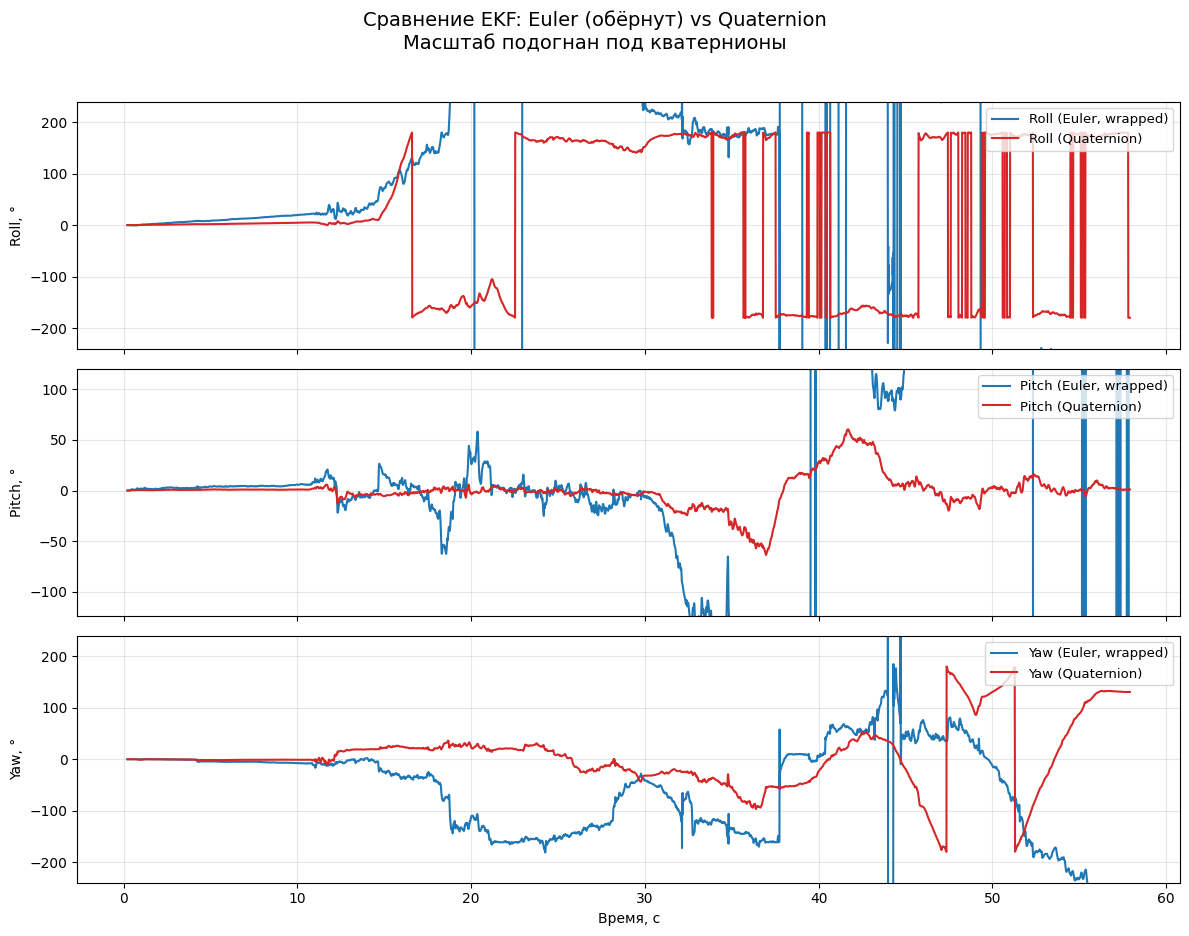

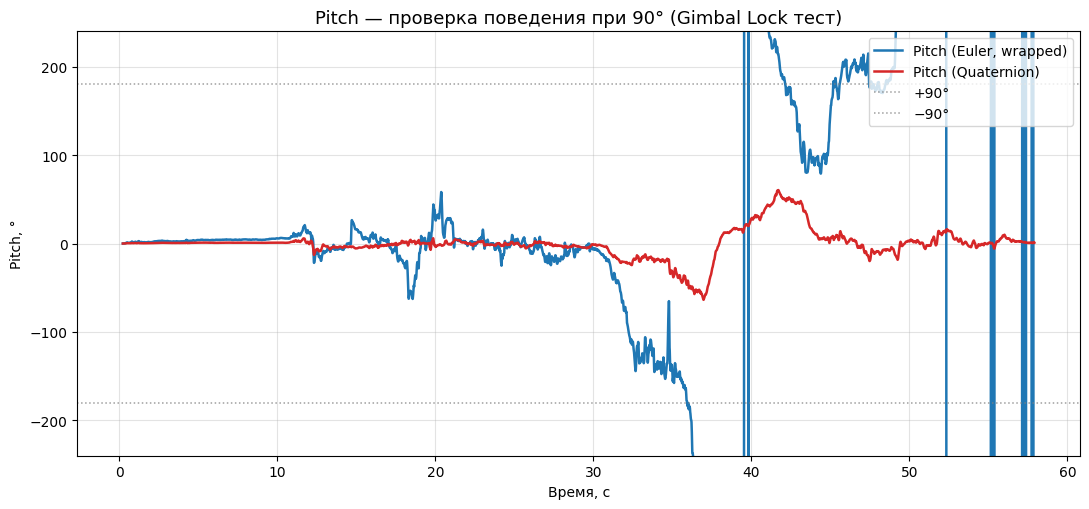

In [28]:
# 1. Оборачиваем углы Эйлера в [-180, 180]
def wrap_angles(angles_deg):
    """Приводит угол к диапазону [-360, +360]"""
    return (angles_deg + 360) % 720 - 360

roll_e   = wrap_angles(np.degrees(euler_hist[:, 0]))
pitch_e  = wrap_angles(np.degrees(euler_hist[:, 1]))
yaw_e    = wrap_angles(np.degrees(euler_hist[:, 2]))

roll_q   = euler_from_quat[:, 0]
pitch_q  = euler_from_quat[:, 1]
yaw_q    = euler_from_quat[:, 2]

COLOR_EULER = '#1f77b4'
COLOR_QUAT  = '#d62728'

# 2. Сравнение всех трёх углов
fig, axs = plt.subplots(3, 1, figsize=(12, 9.5), sharex=True)
fig.suptitle("Сравнение EKF: Euler (обёрнут) vs Quaternion\nМасштаб подогнан под кватернионы", fontsize=14)

for i, (title, e_val, q_val) in enumerate([
    ("Roll",  roll_e,  roll_q),
    ("Pitch", pitch_e, pitch_q),
    ("Yaw",   yaw_e,   yaw_q)
]):
    axs[i].plot(t, e_val, label=f'{title} (Euler, wrapped)', color=COLOR_EULER, lw=1.5)
    axs[i].plot(t, q_val, label=f'{title} (Quaternion)',     color=COLOR_QUAT,  lw=1.5)

    # Ограничение по диапазону кватерниона
    min_q = np.min(q_val) - 60
    max_q = np.max(q_val) + 60
    axs[i].set_ylim(min_q, max_q)

    axs[i].set_ylabel(f'{title}, °')
    axs[i].grid(True, alpha=0.3)
    axs[i].legend(loc='upper right', fontsize=9.5)

axs[2].set_xlabel('Время, с')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# 3. Отдельный график только для Pitch
plt.figure(figsize=(11, 5.2))
plt.title("Pitch — проверка поведения при 90° (Gimbal Lock тест)", fontsize=13)

plt.plot(t, pitch_e, label='Pitch (Euler, wrapped)', color=COLOR_EULER, lw=1.8)
plt.plot(t, pitch_q, label='Pitch (Quaternion)',     color=COLOR_QUAT,  lw=1.8)

plt.axhline(180,  color='gray', ls=':', lw=1.1, alpha=0.75, label='+90°')
plt.axhline(-180, color='gray', ls=':', lw=1.1, alpha=0.75, label='−90°')

plt.ylim(-240, 240)
plt.xlabel('Время, с')
plt.ylabel('Pitch, °')
plt.grid(True, alpha=0.35)
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()